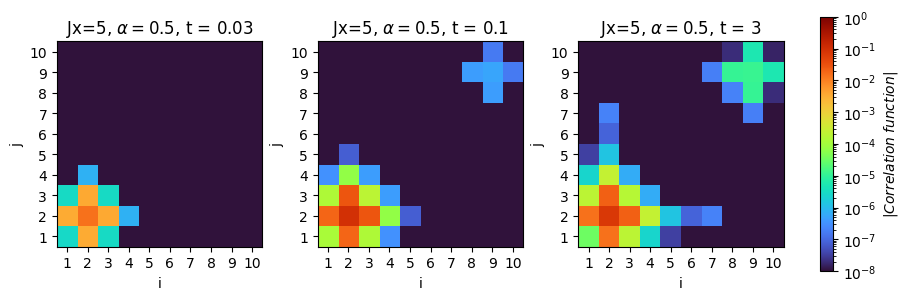

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# -----------------------------
# User settings
# -----------------------------
base_path = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR"
filename = "2dN10Jx55CorrelationFunction.txt"
file_path = os.path.join(base_path, filename)

L = 10  # LxL lattice

# Option A: explicit times (in your file units)
times_to_plot = [0.03,0.1, 3]

# Matching tolerance when selecting a time (since time grid may not hit exactly)
time_tol = 5e-3

# Small floor to avoid zeros in LogNorm (used only if you want auto vmin)
eps = 1e-8

# -----------------------------
# Load data ONLY up to tmax
# -----------------------------
tmax = max(times_to_plot) + time_tol

t_list = []
corr_list = []

with open(file_path, "r") as f:
    for line in f:
        if not line.strip():
            continue

        row = np.fromstring(line, sep=" ")
        t = row[0]

        if t > tmax:
            break   # STOP reading further

        t_list.append(t)
        corr_list.append(np.abs(row[1:]))

t_all = np.array(t_list)
corr_all = np.array(corr_list)

ns = corr_all.shape[1]
if ns != L * L:
    raise ValueError(f"File has ns={ns} columns, but L*L={L*L}. Set L accordingly.")


# -----------------------------
# Helpers
# -----------------------------
def nearest_time_index(t_target, t_vec, tol):
    idx = int(np.argmin(np.abs(t_vec - t_target)))
    dt = abs(t_vec[idx] - t_target)
    if dt > tol:
        print(f"[warn] nearest time to {t_target} is {t_vec[idx]:.6f} (|Δ|={dt:.3e})")
    return idx

def vec_to_grid(v, L):
    return v.reshape((L, L))

# -----------------------------
# Choose snapshots (by time)
# -----------------------------
snapshots = []
for tt in times_to_plot:
    idx = nearest_time_index(tt, t_all, time_tol)
    snapshots.append((t_all[idx], corr_all[idx]))

if len(snapshots) == 0:
    raise RuntimeError("No snapshots selected. Check times_to_plot.")

# -----------------------------
# Log color scale
# (you set these manually; keep them if you want fixed scale)
# -----------------------------
vmin = 1e-8
vmax = 1.0

# If you prefer auto-scale instead, comment the two lines above and use:
# all_vals = np.concatenate([v for _, v in snapshots])
# pos_vals = all_vals[all_vals > 0]
# vmin = max(float(np.min(pos_vals)), eps)
# vmax = float(np.max(pos_vals))

# -----------------------------
# Plot
# -----------------------------
nplots = len(snapshots)
fig, axes = plt.subplots(1, nplots, figsize=(3 * nplots, 3), constrained_layout=True)
if nplots == 1:
    axes = [axes]

im0 = None
for ax, (t_snap, vec) in zip(axes, snapshots):
    grid = vec_to_grid(vec, L)

    im = ax.imshow(
        grid,
        origin="lower",
        interpolation="nearest",
        cmap="turbo",
        norm=LogNorm(vmin=vmin, vmax=vmax),
    )
    if im0 is None:
        im0 = im

    ax.set_title(fr"Jx=5, $\alpha=0.5$, t = {t_snap:.6g}")
    ax.set_xlabel("i")
    ax.set_ylabel("j")
    ax.set_xticks(range(L))
    ax.set_yticks(range(L))
    ax.set_xticklabels(range(1, L + 1))
    ax.set_yticklabels(range(1, L + 1))


cbar = fig.colorbar(im0, ax=axes, shrink=0.9)
cbar.set_label(r"$|Correlation\; function|$")
plt.savefig("plt/2dIsingN10Jx5.pdf")
plt.show()


In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.animation import FuncAnimation, PillowWriter

# -----------------------------
# User settings
# -----------------------------
base_path = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR"
filename = "2dN10Jx55CorrelationFunction.txt"
file_path = os.path.join(base_path, filename)

output_gif = "2dIsing/2dN10Jx55CorrelationFunction.gif"

L = 10              # LxL lattice
fps = 10            # frames per second in GIF
frame_stride = 1    # use every nth timestep (increase if file is large)

# Small floor to avoid zeros in LogNorm (only used for auto-scaling if you choose)
eps = 1e-8

# -----------------------------
# Load data
# Expected format: t  c[0] c[1] ... c[ns-1]
# -----------------------------
data = np.loadtxt(file_path)
t_all = data[:, 0]
corr_all = np.abs(data[:, 1:])  # (nt, ns)

nt, ns = corr_all.shape
if ns != L * L:
    raise ValueError(f"File has ns={ns} columns, but L*L={L*L}. Set L accordingly.")

# Subsample time if needed
t_all = t_all[::frame_stride]
corr_all = corr_all[::frame_stride]
nt = len(t_all)

# Make data LogNorm-safe
corr_all = np.nan_to_num(corr_all, nan=vmin, posinf=vmax, neginf=vmin)
corr_all[corr_all <= 0] = vmin


# -----------------------------
# Helpers
# -----------------------------
def vec_to_grid(v, L):
    return v.reshape((L, L))

# -----------------------------
# Global log color scale (fixed, manual)
# -----------------------------
# If you want auto-scale instead, see the commented block below.
vmin = 1e-8
vmax = 1.0

# ---- Auto-scale option (uncomment to use) ----
# all_vals = corr_all.flatten()
# pos_vals = all_vals[all_vals > 0]
# if pos_vals.size == 0:
#     raise ValueError("All correlation values are zero; cannot use LogNorm.")
# vmin = max(float(np.min(pos_vals)), eps)
# vmax = float(np.max(pos_vals))
# ---------------------------------------------

norm = LogNorm(vmin=vmin, vmax=vmax)

# Diagnose frames that contain invalid values for LogNorm
bad_mask = ~np.isfinite(corr_all) | (corr_all <= 0)
bad_counts = bad_mask.sum(axis=1)

print("Frames with any invalid (<=0 or NaN/inf):", np.where(bad_counts > 0)[0][:20])
print("Max invalid count in a frame:", bad_counts.max())

# Also check saturation (values hitting vmax, which can look very bright)
sat_counts = (corr_all >= vmax).sum(axis=1)
print("Frames with any saturated (>=vmax):", np.where(sat_counts > 0)[0][:20])
print("Max saturated count in a frame:", sat_counts.max())


# -----------------------------
# Figure setup
# -----------------------------
fig, ax = plt.subplots(figsize=(3, 3))

grid0 = vec_to_grid(corr_all[0], L)
im = ax.imshow(
    grid0,
    origin="lower",
    cmap="turbo",
    norm=norm,
    interpolation="nearest",
)

ax.set_xlabel("i")
ax.set_ylabel("j")
ax.set_xticks(range(L))
ax.set_yticks(range(L))
ax.set_xticklabels(range(1, L + 1))
ax.set_yticklabels(range(1, L + 1))

title = ax.set_title(f"t = {t_all[0]:.6g}")

cbar = fig.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label(r"$|Correlation function|$")

# -----------------------------
# Animation update function
# -----------------------------
def update(frame):
    grid = vec_to_grid(corr_all[frame], L)
    im.set_data(grid)
    title.set_text(f"t = {t_all[frame]:.6g}")
    return im, title

# -----------------------------
# Create animation
# -----------------------------
anim = FuncAnimation(
    fig,
    update,
    frames=nt,
    interval=1000 // fps,
    blit=False,
)

# -----------------------------
# Save GIF
# -----------------------------
writer = PillowWriter(fps=fps)
anim.save(output_gif, writer=writer)

plt.close(fig)
print(f"GIF saved to: {output_gif}")


Frames with any invalid (<=0 or NaN/inf): []
Max invalid count in a frame: 0
Frames with any saturated (>=vmax): []
Max saturated count in a frame: 0
GIF saved to: 2dIsing/2dN10Jx55CorrelationFunction.gif


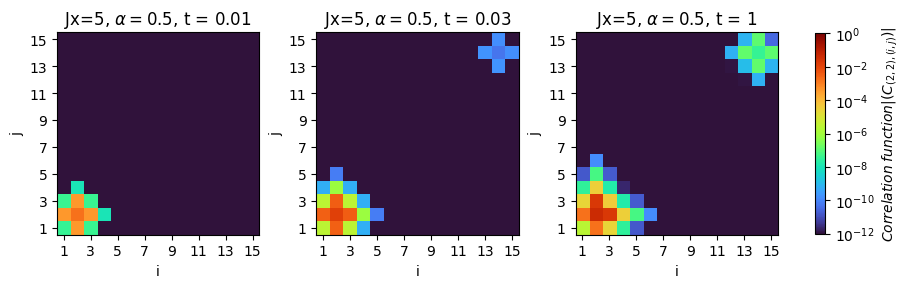

In [21]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# -----------------------------
# User settings
# -----------------------------
base_path = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR"
filename = "2dN15Jx55CorrelationFunction.txt"
file_path = os.path.join(base_path, filename)

L = 15  # LxL lattice

# Option A: explicit times (in your file units)
times_to_plot = [0.01, 0.03,1]

# Matching tolerance when selecting a time (since time grid may not hit exactly)
time_tol = 5e-3

# Small floor to avoid zeros in LogNorm (used only if you want auto vmin)
eps = 1e-8

# -----------------------------
# Load data ONLY up to tmax
# -----------------------------
tmax = max(times_to_plot) + time_tol

t_list = []
corr_list = []

with open(file_path, "r") as f:
    for line in f:
        if not line.strip():
            continue

        row = np.fromstring(line, sep=" ")
        t = row[0]

        if t > tmax:
            break   # STOP reading further

        t_list.append(t)
        corr_list.append(np.abs(row[1:]))

t_all = np.array(t_list)
corr_all = np.array(corr_list)

ns = corr_all.shape[1]
if ns != L * L:
    raise ValueError(f"File has ns={ns} columns, but L*L={L*L}. Set L accordingly.")


# -----------------------------
# Helpers
# -----------------------------
def nearest_time_index(t_target, t_vec, tol):
    idx = int(np.argmin(np.abs(t_vec - t_target)))
    dt = abs(t_vec[idx] - t_target)
    if dt > tol:
        print(f"[warn] nearest time to {t_target} is {t_vec[idx]:.6f} (|Δ|={dt:.3e})")
    return idx

def vec_to_grid(v, L):
    return v.reshape((L, L))

# -----------------------------
# Choose snapshots (by time)
# -----------------------------
snapshots = []
for tt in times_to_plot:
    idx = nearest_time_index(tt, t_all, time_tol)
    snapshots.append((t_all[idx], corr_all[idx]))

if len(snapshots) == 0:
    raise RuntimeError("No snapshots selected. Check times_to_plot.")

# -----------------------------
# Log color scale
# (you set these manually; keep them if you want fixed scale)
# -----------------------------
vmin = 1e-12
vmax = 1.0

# If you prefer auto-scale instead, comment the two lines above and use:
# all_vals = np.concatenate([v for _, v in snapshots])
# pos_vals = all_vals[all_vals > 0]
# vmin = max(float(np.min(pos_vals)), eps)
# vmax = float(np.max(pos_vals))

# -----------------------------
# Plot
# -----------------------------
nplots = len(snapshots)
fig, axes = plt.subplots(1, nplots, figsize=(3 * nplots, 3), constrained_layout=True)
if nplots == 1:
    axes = [axes]

im0 = None
for ax, (t_snap, vec) in zip(axes, snapshots):
    grid = vec_to_grid(vec, L)

    im = ax.imshow(
        grid,
        origin="lower",
        interpolation="nearest",
        cmap="turbo",
        norm=LogNorm(vmin=vmin, vmax=vmax),
    )
    if im0 is None:
        im0 = im

    ax.set_title(fr"Jx=5, $\alpha=0.5$, t = {t_snap:.6g}")
    ax.set_xlabel("i")
    ax.set_ylabel("j")
    ax.set_xticks(range(0,L,2))
    ax.set_yticks(range(0,L,2))
    ax.set_xticklabels(range(1, L + 1,2))
    ax.set_yticklabels(range(1, L + 1,2))


cbar = fig.colorbar(im0, ax=axes, shrink=0.7)
cbar.set_label(r"$ Correlation\; function |(C_{(2,2),(i,j)})|$")
plt.savefig("plt/2dIsingN10Jx5.pdf")
plt.show()


In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.animation import FuncAnimation, PillowWriter

# -----------------------------
# User settings
# -----------------------------
base_path = r"D:\OneDrive - Tulane University\RESEARCH\Quantum transport\Code\Plots\B0LFIMwithLR"
filename = "2dN15Jx55CorrelationFunction.txt"
file_path = os.path.join(base_path, filename)

output_gif = "2dIsing/2dN15Jx55CorrelationFunction.gif"

L = 15              # LxL lattice
fps = 10            # frames per second in GIF
frame_stride = 1    # use every nth timestep (increase if file is large)

# Small floor to avoid zeros in LogNorm (only used for auto-scaling if you choose)
eps = 1e-8

# -----------------------------
# Load data
# Expected format: t  c[0] c[1] ... c[ns-1]
# -----------------------------
data = np.loadtxt(file_path)
t_all = data[:, 0]
corr_all = np.abs(data[:, 1:])  # (nt, ns)

nt, ns = corr_all.shape
if ns != L * L:
    raise ValueError(f"File has ns={ns} columns, but L*L={L*L}. Set L accordingly.")

# Subsample time if needed
t_all = t_all[::frame_stride]
corr_all = corr_all[::frame_stride]
nt = len(t_all)

# Make data LogNorm-safe
corr_all = np.nan_to_num(corr_all, nan=vmin, posinf=vmax, neginf=vmin)
corr_all[corr_all <= 0] = vmin


# -----------------------------
# Helpers
# -----------------------------
def vec_to_grid(v, L):
    return v.reshape((L, L))

# -----------------------------
# Global log color scale (fixed, manual)
# -----------------------------
# If you want auto-scale instead, see the commented block below.
vmin = 1e-12
vmax = 1.0

# ---- Auto-scale option (uncomment to use) ----
# all_vals = corr_all.flatten()
# pos_vals = all_vals[all_vals > 0]
# if pos_vals.size == 0:
#     raise ValueError("All correlation values are zero; cannot use LogNorm.")
# vmin = max(float(np.min(pos_vals)), eps)
# vmax = float(np.max(pos_vals))
# ---------------------------------------------

norm = LogNorm(vmin=vmin, vmax=vmax)

# Diagnose frames that contain invalid values for LogNorm
bad_mask = ~np.isfinite(corr_all) | (corr_all <= 0)
bad_counts = bad_mask.sum(axis=1)

print("Frames with any invalid (<=0 or NaN/inf):", np.where(bad_counts > 0)[0][:20])
print("Max invalid count in a frame:", bad_counts.max())

# Also check saturation (values hitting vmax, which can look very bright)
sat_counts = (corr_all >= vmax).sum(axis=1)
print("Frames with any saturated (>=vmax):", np.where(sat_counts > 0)[0][:20])
print("Max saturated count in a frame:", sat_counts.max())


# -----------------------------
# Figure setup
# -----------------------------
fig, ax = plt.subplots(figsize=(5, 5))

grid0 = vec_to_grid(corr_all[0], L)
im = ax.imshow(
    grid0,
    origin="lower",
    cmap="turbo",
    norm=norm,
    interpolation="nearest",
)

ax.set_xlabel("i")
ax.set_ylabel("j")
ax.set_xticks(range(L))
ax.set_yticks(range(L))
ax.set_xticklabels(range(1, L + 1))
ax.set_yticklabels(range(1, L + 1))

title = ax.set_title(f"t = {t_all[0]:.6g}")

cbar = fig.colorbar(im, ax=ax, shrink=0.85)
cbar.set_label(r"$|Correlation\; function (C_{(2,2),(i,j)})|$")

# -----------------------------
# Animation update function
# -----------------------------
def update(frame):
    grid = vec_to_grid(corr_all[frame], L)
    im.set_data(grid)
    title.set_text(f"t = {t_all[frame]:.6g}")
    return im, title

# -----------------------------
# Create animation
# -----------------------------
anim = FuncAnimation(
    fig,
    update,
    frames=nt,
    interval=1000 // fps,
    blit=False,
)

# -----------------------------
# Save GIF
# -----------------------------
writer = PillowWriter(fps=fps)
anim.save(output_gif, writer=writer)

plt.close(fig)
print(f"GIF saved to: {output_gif}")


Frames with any invalid (<=0 or NaN/inf): []
Max invalid count in a frame: 0
Frames with any saturated (>=vmax): []
Max saturated count in a frame: 0
GIF saved to: 2dIsing/2dN15Jx55CorrelationFunction.gif
